# Turbulent flux response to a longwave radiative forcing

The sensible heat flux is not independent of the radiation field. It is a bulk
flux driven by the skin-to-air temperature difference,

$$SH_{up} \;\approx\; \rho\, c_p\, C_H\, U \,(T_{skin} - T_{2m})$$

so lowering the downwelling longwave over a surface with little heat capacity
cools the skin, shrinks $(T_{skin} - T_{2m})$, and weakens the turbulent flux
that had been carrying heat away. The turbulent term therefore **damps** the
longwave forcing: it gives back part of what the radiation took. *How much* it
gives back is a property of the surface, because the skin temperature's freedom
to move is a property of the surface.

## Sign convention — read this before interpreting any number

Every ERA5 surface flux here is stored **positive downward, into the surface**:

| `msshf` | meaning |
|---|---|
| $> 0$ | heat flowing from the air **into** the surface |
| $< 0$ | heat flowing from the surface **into** the air (upward SH) |

Under liquid-bearing overcast on the Barrow strip $T_{skin}$ exceeds $T_{2m}$
most of the time, so `msshf` is typically **negative** there — the flux is
carrying heat *up*, out of the surface. A DLR decrease then cools the skin,
shrinks the skin-to-air difference, and makes `msshf` *less* negative: the
upward flux weakens, less heat leaves the surface, and the cooling is damped.

Over pack ice in midwinter the sign often reverses ($T_{skin} < T_{2m}$ under
the surface inversion, `msshf` $> 0$), and there the same DLR decrease
*strengthens* a downward flux. **Both are damping.** The sign of the flux is not
the sign of the feedback, which is why nothing below averages the two regimes
together.

## The important caveat

Nothing here is a controlled forcing experiment. Every slope is a **covariance
across the natural synoptic variability of the record**: hours with high DLR are
cloudy, and cloudy hours also differ in wind speed, air mass origin, and
boundary-layer stability. Read the numbers as *how the surface state co-varies
with DLR*. Two estimators are reported throughout and they bracket the causal
answer from opposite sides — see the "Two estimators" section below.

## What this notebook contains

| Cell | Figure |
|---|---|
| Load | one streaming pass; everything below is drawn from it |
| Report | the numbers the figures draw |
| 1 | LWP against SHF, density-coloured, per surface class, with a linear fit |
| 2 | DLR against SHF, same treatment |
| 3 | $(T_{skin}-T_{2m})$ against SHF — the bulk relation itself |
| 4 | the partition of $d(LWD)$ by surface class |
| 5 | the marginal ice zone as a natural experiment |

All analysis lives in `turbulent_flux_response.py`; this notebook holds none of
its own, so the two cannot drift apart. Editing the module and re-running a
figure cell picks up the change (autoreload is on).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import turbulent_flux_response as tfr

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use dpi=

# Set to a directory to write PNGs as well as display them; None displays only.
SAVE_DIR = Path("figures/turbulent_response")
DPI = 350

# What the scatter figures draw over the density. "default" is the
# cos(latitude)-weighted fit plus the mean of y in each x column; "regression"
# is the unweighted least-squares regression alone, as a thin solid black line.
# Both are accumulated in the same pass, so this can be changed on an existing
# `A` without reloading -- every figure cell below takes fit_mode= too.
FIT_MODE = "regression"

## Load the data

The slow cell, and the only one that touches the archive. Everything the five
figures need — both populations, both sensitivity groupings, all three density
histograms — is accumulated in this single streaming pass, so re-running a
figure cell costs a second.

The cloud-phase masks are **imported** from
`plot_lwp_histogram_by_surface_class.py` rather than restated, so this notebook
cannot drift from the ones that draw the LWP histograms and the Genie
comparison.

- **cloudy**: `tcc >= min_cloud_fraction` (0.99, effectively overcast)
- **liquid-bearing**: the union of that module's *liquid-only* and *mixed-phase*
  categories — everything holding cloud water that is not classed as ice-only.

### The phase scheme: fractional, matching `comparison_with_Genie_Obs.ipynb`

Phase is decided by **each species' share of the cloud water path**,
$CWP = LWP + IWP$, not by absolute g m⁻² thresholds:

| category | condition |
|---|---|
| liquid only | $LWP/CWP \geq 0.90$ |
| ice only | $IWP/CWP \geq 0.85$ |
| mixed phase | anything else holding cloud water |

with an absolute floor of **0.01 g m⁻²** on each species below which it counts
as absent — that floor is what keeps the ratio off numerical dust, since a
scene with 0.005 g m⁻² of liquid and nothing else is 100% liquid *by share*.

The three are exhaustive and disjoint over scenes carrying cloud water, so
**liquid-bearing here means liquid fraction above 0.15** — i.e. everything
except ice-only. That is the same binary split
`comparison_with_Genie_Obs.ipynb` uses against Genie's observations, which is
the point of matching it: the population in these figures is now the one the
ARM comparison is calibrated on.

**This is a different population from the absolute scheme**, not a
relabelling of it. The fraction scheme *admits* thin liquid-dominated clouds
that an absolute LWP floor would reject, and *rejects* ice-dominated clouds
carrying a trace of liquid that an absolute scheme would call mixed-phase. In
Arctic autumn the second effect wins, so the sample shrinks by roughly 10–20%
per surface class relative to the absolute defaults.

> **One deliberate difference from the Genie notebook.** That notebook uses
> `min_cloud_fraction=0.909`; this one keeps **0.99**, the overcast gate used
> throughout the rest of this analysis. The gate is a cloudy-scene definition,
> not a phase definition, so it is left as it was — set it to `0.909` in the
> cell below if you want the two notebooks to describe exactly the same hours.

`prepare()` takes the same options as the command line, by keyword. Anything
left out keeps its default.

In [2]:
A = tfr.prepare(
    region="barrow",
    years=tuple(range(2020, 2026)),   # season START years -> 2022/23 .. 2025/26
    season_start=(10, 1),
    season_end=(3, 31),

    # --- cloud phase: fractional scheme, same values as
    # --- comparison_with_Genie_Obs.ipynb
    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.850,           # IWP/CWP at or above this = ice only
                                      # (mixed phase is everything else)
    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.96,          # overcast gate (Genie notebook: 0.909)
    fit_mode=FIT_MODE,                # scatter overlay; changeable without reload
    lsm_tol=0.01,                     # land-sea mask tolerance
    open_ocean_max_siconc=0.05,       # below this: open ocean
    sea_ice_min_siconc=0.95,          # above this: pack ice; between: MIZ
    storage="local",
    dpi=DPI,
)

Turbulent flux response to longwave forcing, by surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.96
  Liquid-bearing: liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
  Precip     : no precipitation filter

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 10

## Numeric report

Sample sizes, the three scatter fits, and the DLR partition per class — the
numbers the figures draw, in a form that can be pasted into a note. Both
estimators are printed. Optional; the figures do not depend on it.

In [3]:
tfr.print_report(A)


Population: liquid-bearing overcast   |   seasons 2020-2025   |   region barrow
  valid cell-hours           65,606,232
  overcast cell-hours        46,599,842  (71.0% of valid)
  in this population         24,186,635
  ARM site cell          71.25 N, -156.50 E
  site cell class share  Coastal (mixed) 100%

  LWP  vs  sensible heat flux   (OLS fit of y on x: y = a + b x)
                                                           --- cos(lat) weighted ---    ---- unweighted ----
    class                       hours    x_mean    y_mean       slope     r2       r        slope     r2
    Land                       89,770      9.15     46.90      0.4180  0.011   0.105       0.4180  0.011
    Coastal (mixed)         1,845,956     -7.75     45.44      0.0880  0.004   0.063       0.0862  0.004
    Open ocean              2,546,683    -44.83     87.92     -0.0380  0.001  -0.035      -0.0381  0.001
    Marginal ice zone       5,297,059    -27.81     43.42      0.0737  0.006   0.077       0.083

## Figures 1 and 2 — the two the question asks for

Each panel is a **density-coloured scatter**: the joint distribution of the two
variables over every cell-hour of the population, binned on a 180 × 180 grid,
with each occupied bin drawn as a marker coloured by its area-weighted
frequency. Colour is normalised to *the densest bin in that panel*, because the
classes differ in size by three orders of magnitude — the ARM site is one grid
cell, sea ice is thousands — and a shared scale would flatten most of the
figure. The cell-hour count is printed on each panel instead.

Every panel is annotated with the **slope**, **r²**, and the cell-hour count.
r² is the square of the Pearson correlation, which for a simple OLS fit is also
the fraction of the variance in y the fit explains. Expect it to be small on
figures 1 and 2 — those are two-step relations (LWP → DLR → $T_{skin}$ → SHF) —
and read it as *how much of the scatter one straight line accounts for*, not as
a verdict on whether the mechanism is present. Figure 3, which is the bulk
relation itself, is where r² should and does get large.

### The two fit modes

`FIT_MODE` above selects what is drawn over the density. **Both fit the same
model, $y = a + bx$, by ordinary least squares on the full unbinned sample —
never on the binned histogram, which exists only for drawing.** They differ in
the denominator and in the rendering:

| `fit_mode` | line | weighting | drawn beside it |
|---|---|---|---|
| `"default"` | red dashed | by cos(latitude) | the mean of y in each x column |
| `"regression"` | thin solid black | none, every cell-hour once | nothing |

Neither is a correction of the other. Area weighting is the right denominator
for a statement about *the region* — a cell at 79 °N covers half the ground of
one at 70 °N. No weighting is the right denominator for a statement about *the
sample*, and is what a reader comparing against a point measurement or a
published scatter plot will assume. On this domain the two agree to about 1%,
because cos(latitude) only varies by a factor of two across 70–80 °N; the
report prints both side by side so that agreement is checkable rather than
asserted.

In `"default"` mode the binned-mean curve is there to show **where the straight
line misrepresents a relation that bends**, which on a variable as skewed as LWP
it always does somewhere. `"regression"` mode drops it so the conventional
single-line presentation is uncluttered.

The fit line is drawn only across the x range the data actually occupy — the
Utqiagvik cell spans about 30 W m⁻² of an axis 310 wide, and an extrapolated
line there reads as a claim the fit cannot support.

### 1. Liquid water path against sensible heat flux

Read this as a joint distribution, not a causal chain. LWP does not drive SHF
directly: it drives DLR, which drives $T_{skin}$, which drives SHF. The
straight-line fit summarises a two-step relation and is not expected to be
tight — what it is good for is the **sign** and the **contrast between
classes**.

  -> figures/turbulent_response/barrow_shf_vs_lwp_regression_mean2020-2025.png


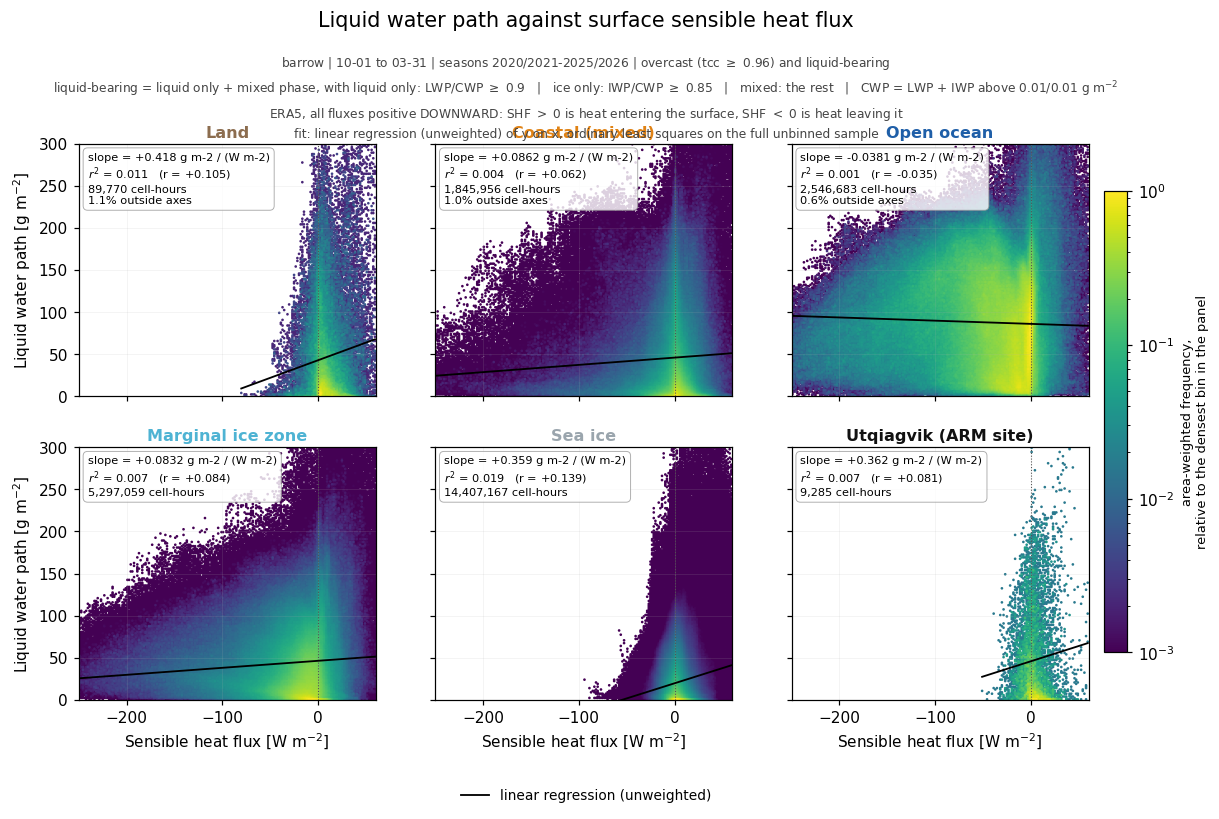

In [4]:
tfr.fig_shf_vs_lwp(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

### 2. Downwelling longwave against sensible heat flux

The same population with the intermediate variable substituted in. DLR is what
the cloud actually delivers to the surface, so this is one step closer to the
mechanism and the relation is correspondingly tighter.

  -> figures/turbulent_response/barrow_shf_vs_dlr_regression_mean2020-2025.png


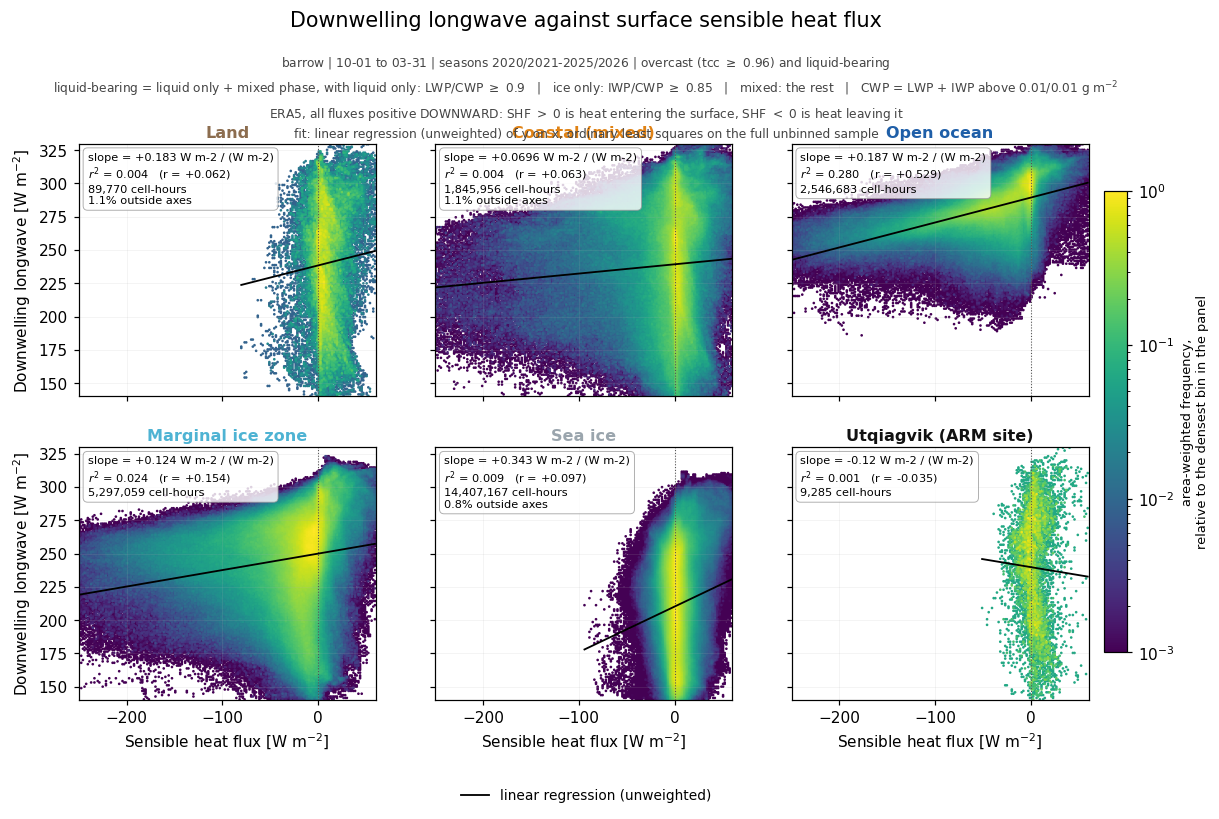

In [5]:
tfr.fig_shf_vs_dlr(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

### 3. The bulk relation itself

Not requested, but it is the premise figures 1 and 2 rest on, and it costs
nothing to draw from the same pass. If ERA5's sensible heat flux is the bulk
flux the argument assumes, this is a line through the origin with slope
$-\rho c_p C_H U$ — and the scatter about it is the wind-speed and stability
dependence that the LWP and DLR panels inherit.

  -> figures/turbulent_response/barrow_shf_vs_dskt_regression_mean2020-2025.png


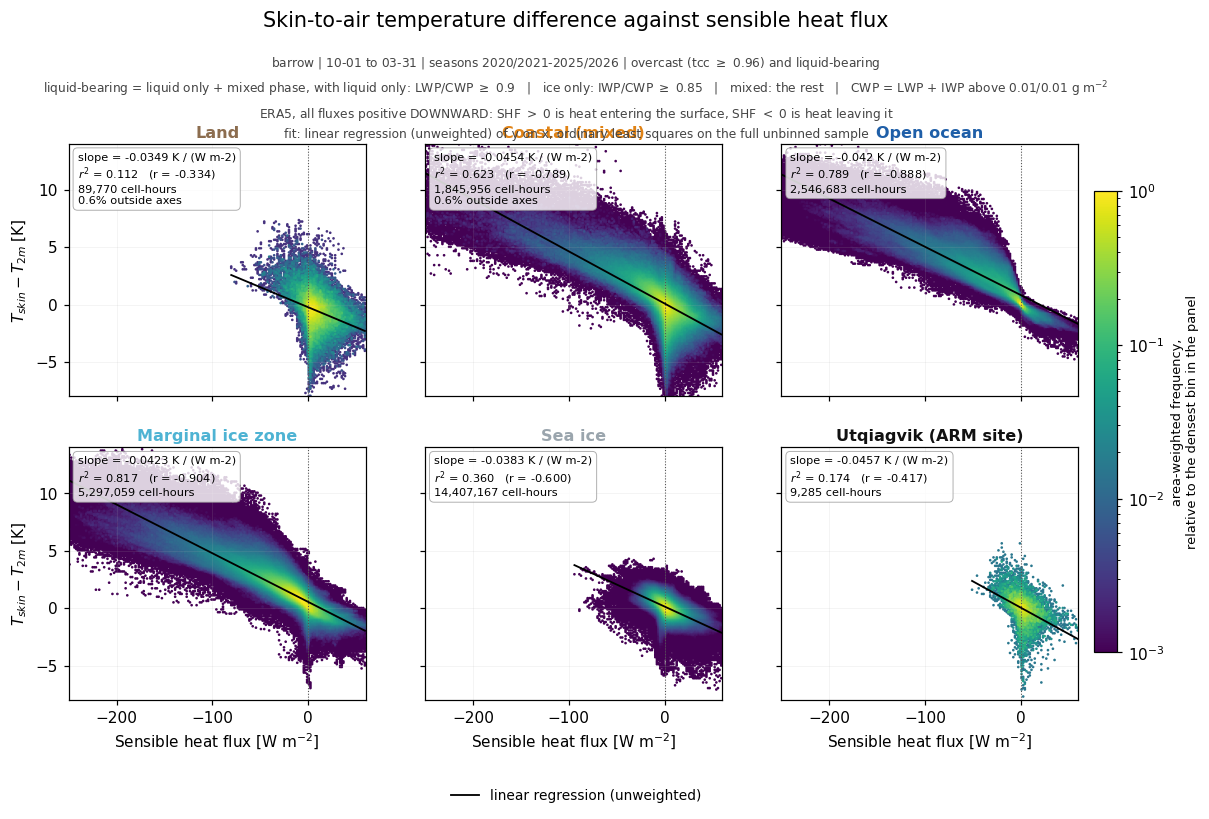

In [6]:
tfr.fig_shf_vs_dskt(A, out_dir=SAVE_DIR, dpi=DPI, fit_mode=FIT_MODE);

## The partition, and how it is estimated

With every term positive downward, the surface energy balance is

$$R = LWD - LWU + SW_{net} + SH + LH \qquad [\mathrm{W\,m^{-2}},\ \text{down}]$$

where $R$ is the net convergence, which over ice goes into conduction, storage
and melt. Differentiating with respect to $LWD$ gives an exact partition of each
additional W m⁻² of DLR:

$$1 = f_{LWU} + f_{SH} + f_{LH} + f_{SW} + f_{res}$$

| term | definition | meaning |
|---|---|---|
| $f_{LWU}$ | $\;\;\,d(LWU)/d(LWD)$ | radiated straight back out (Stefan–Boltzmann) |
| $f_{SH}$ | $-d(\mathtt{msshf})/d(LWD)$ | carried away by upward sensible heat flux |
| $f_{LH}$ | $-d(\mathtt{mslhf})/d(LWD)$ | carried away by upward latent heat flux |
| $f_{SW}$ | $-d(SW_{net})/d(LWD)$ | shortwave co-variation ($\approx 0$ in polar night) |
| $f_{res}$ | $\;\;\,d(R)/d(LWD)$ | left over, into the subsurface / melt |

The five sum to one **by construction**, not by luck: the slope operator is
linear and $d(LWD)/d(LWD) = 1$, so $f_{res}$ is defined as the remainder. That
is what makes the stacked bar a genuine budget rather than a collection of
unrelated regressions.

The companion number, $dT_{skin}/d(LWD)$ in K per W m⁻², is the surface's
**thermal freedom** — and $f_{LWU}$ and $f_{SH}$ are both roughly proportional
to it, which is why they rise and fall together across the ice edge.

### Two estimators, and why both are shown

An hour with high DLR is an hour with a cloud, and an Arctic cloudy hour is
usually an hour of warm, moist advection. So $T_{2m}$ rises with DLR — and the
sensible heat flux responds to $T_{2m}$ directly, through the same bulk formula,
with nothing radiative about it.

- **Plain regression** (the default, drawn as bars). Charges the radiation for
  everything the air mass did too, so it is an **upper bound**. Over open water
  it breaks down completely — the surface is pinned near freezing, so
  essentially the whole skin-to-air difference is the *air* moving, and the
  coefficients exceed one. The figures label that case rather than hiding it.
- **Holding $T_{2m}$ fixed** (drawn as markers). Leaves only the pathway running
  through the surface. But $T_{2m}$ is a **mediator** as well as a confounder —
  over sea ice the air temperature is largely slaved to the skin temperature
  beneath it, so the chain DLR → $T_{skin}$ → $T_{2m}$ is a real part of the
  response, and deleting it biases every sensitivity toward zero. A **lower
  bound**.

Neither is the causal answer. Together they bracket it, and the gap between them
is the size of the air-mass confound. Pass `control="t2m"` to either figure to
swap which is the headline.

### 4. The partition by surface class

Panel (a) carries **two** series, and the second is the one that decides the
sign of the turbulent response:

- **solid bars** — $dT_{skin}/d(LWD)$, the surface's thermal freedom. A surface
  that cannot warm cannot radiate more, so this is what $f_{LWU}$ tracks.
- **hatched bars** — $d(T_{skin}-T_{2m})/d(LWD)$. The sensible heat flux follows
  the skin-to-air *difference*, not the skin temperature, so whether a DLR
  increase strengthens or weakens the upward flux depends on which of the two
  temperatures moves further. Where this is negative the air warms faster than
  the surface, the difference shrinks, and the flux moves energy **into** the
  surface — the turbulent term adds to the radiative warming rather than damping
  it.

Panels (c) and (d) are the underlying binned relations, drawn so the slopes in
(a) and (b) can be checked against the curves they came from — a slope taken
across a curve that bends is a summary, not a coefficient.

  -> figures/turbulent_response/barrow_dlr_partition_cloud_none_mean2020-2025.png


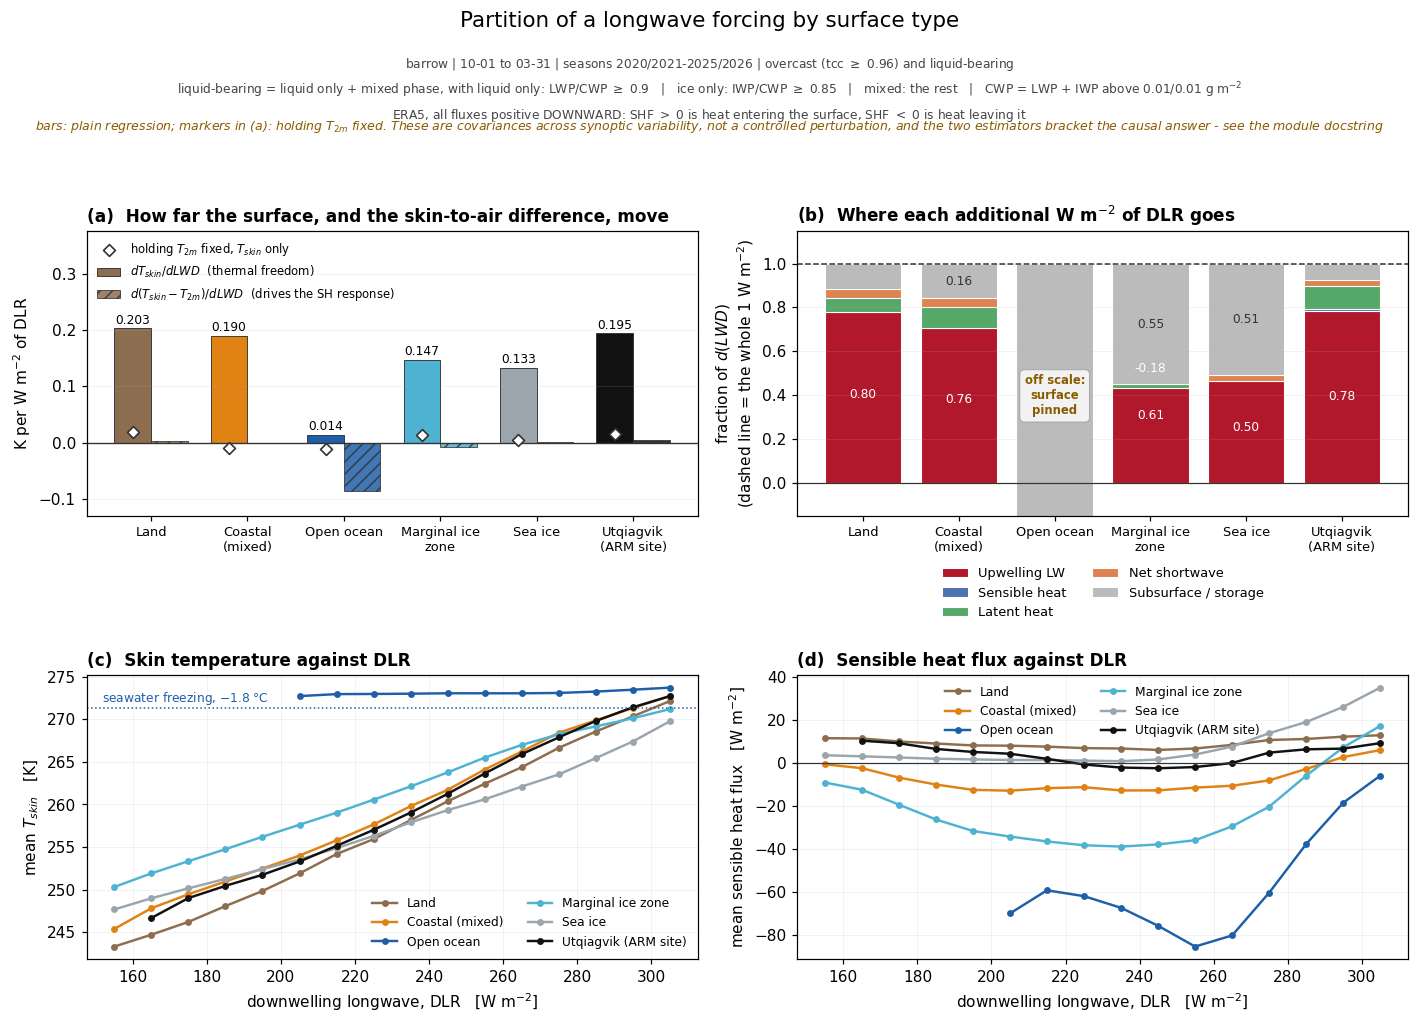

In [7]:
tfr.fig_response_partition(A, out_dir=SAVE_DIR, dpi=DPI);

### 5. The marginal ice zone as a natural experiment

> *Across a short horizontal distance the surface changes from open water near
> −1.8 °C to pack ice tens of degrees colder, while the overlying atmosphere is
> roughly the same air mass. So the marginal ice zone is where the DLR gradient
> and the surface response gradient are both steepest, and comparing them tells
> you how a given change in DLR partitions into skin temperature, upward
> longwave, and turbulent flux — as a function of surface type.*

The three discrete ocean classes cut that continuum into three pieces and then
report a mean for each, which is the wrong shape for the question. Here **sea
ice concentration replaces the class label**, the population is sea cells only,
and the panels read left to right as a transect from open water to pack ice.

- **(a)** sets up the experiment — how much the surface varies across the edge,
  and how much less the forcing does.
- **(b)** is the *surface response gradient*, and it is the direct counterpart
  to the Hovmöller sections of $\partial(DLR)/\partial\mathrm{lat}$ in
  `plot_hovmoller_dlwd_dlat_by_season.ipynb`: that notebook has the **forcing**
  gradient, this panel has the **response** gradient. Three curves —
  $dT_{skin}/d(LWD)$ under both estimators, and
  $d(T_{skin}-T_{2m})/d(LWD)$, which is where the sign of the turbulent
  response is decided.
- **(c)** is the resulting partition, the same five fractions as figure 4 drawn
  as curves. The left end is labelled where the estimator stops meaning what its
  axis says.
- **(d)** is the turbulent flux and its driver, which change sign together
  somewhere inside the band.

  -> figures/turbulent_response/barrow_miz_transect_cloud_none_mean2020-2025.png


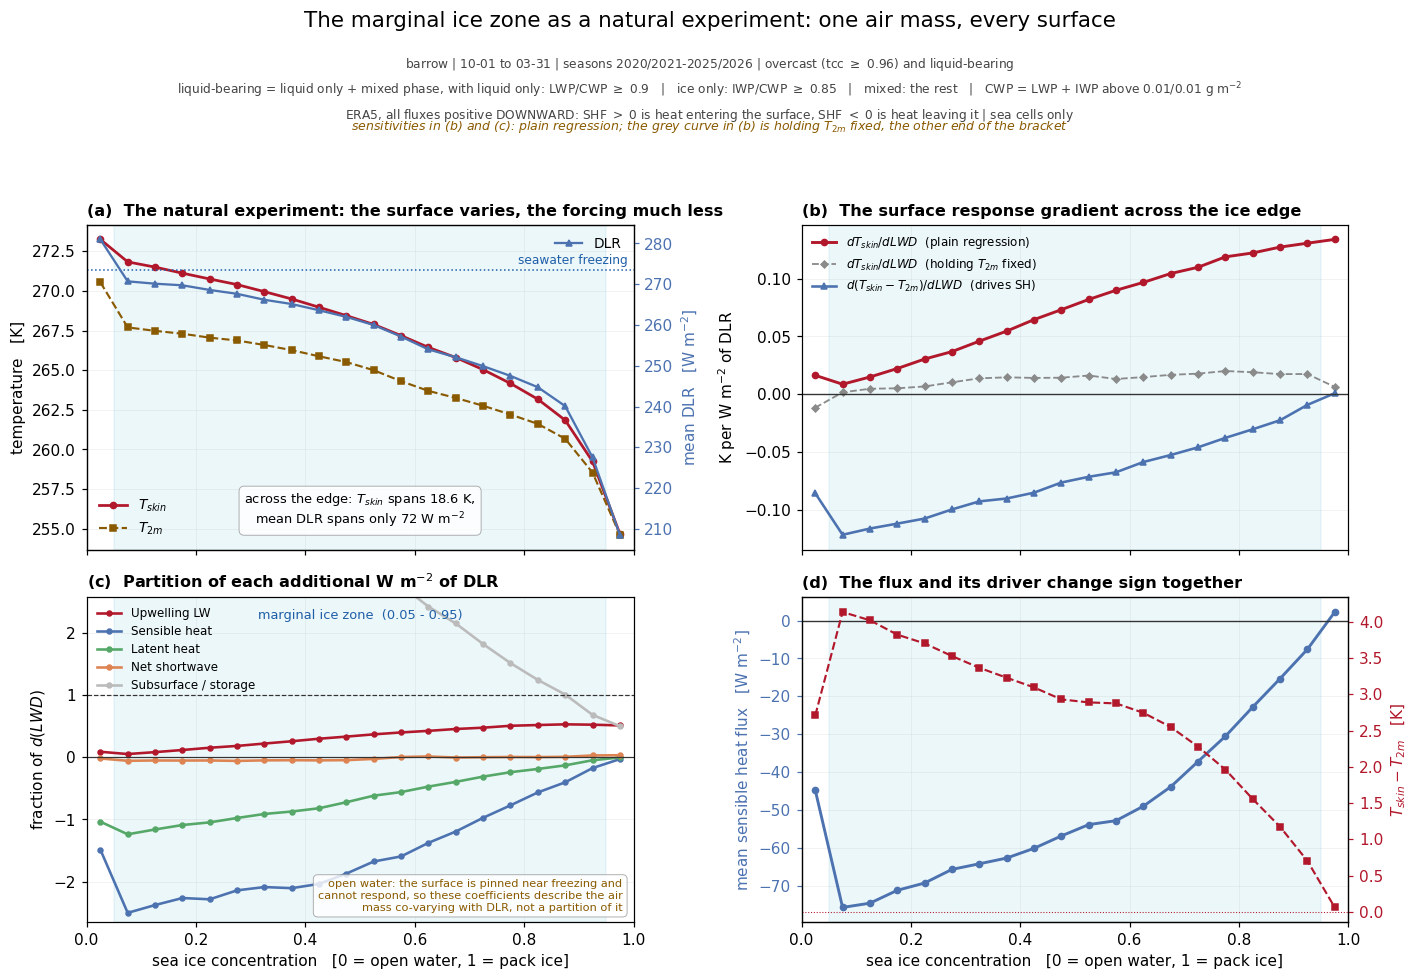

In [8]:
tfr.fig_miz_transect(A, out_dir=SAVE_DIR, dpi=DPI);

## What this record actually shows

Barrow strip, Oct–Mar, seasons 2022/23–2025/26, overcast and liquid-bearing
under the **fractional** phase scheme above: 14.08 million cell-hours. Plain
regression unless noted.

**0. What changing the phase scheme did.** Moving from the absolute g m⁻²
thresholds to the fractional scheme costs 8.2% of the sample overall, and the
loss is strongly class-dependent — it falls hardest where clouds are
ice-dominated:

| class | absolute | fractional | change |
|---|---|---|---|
| Land | 58,398 | 45,503 | −22.1% |
| Coastal | 1,174,261 | 971,315 | −17.3% |
| Open ocean | 1,860,811 | 1,612,281 | −13.4% |
| Marginal ice zone | 3,503,188 | 3,158,254 | −9.8% |
| Sea ice | 8,750,537 | 8,295,478 | −5.2% |
| **All** | **15,347,195** | **14,082,831** | **−8.2%** |

The scheme change moves every number by a few percent and moves **none of the
conclusions**, which is the useful result: what follows is a property of the
atmosphere, not of where the phase threshold was put.

**1. The bulk relation holds, tightly.** Figure 3 gives
$d(\mathtt{msshf})/d(T_{skin}-T_{2m}) \approx -24$ to $-27$ W m⁻² K⁻¹ with
r² = 0.37–0.83 over ocean and ice (0.13 over the small land sample). ERA5's
sensible heat flux is the bulk flux the argument assumes, so the mechanism is
available in principle.

**2. But the skin-to-air difference barely responds to DLR over land or ice.**
$T_{skin}$ and $T_{2m}$ move together almost one-for-one:

| class | $dT_{skin}/dLWD$ | $dT_{2m}/dLWD$ | $d(T_{skin}-T_{2m})/dLWD$ |
|---|---|---|---|
| Land | 0.198 | 0.195 | +0.003 |
| Marginal ice zone | 0.149 | 0.157 | −0.007 |
| Sea ice | 0.131 | 0.131 | −0.000 |
| Open ocean | 0.017 | 0.117 | **−0.100** |

(K per W m⁻²). Over ice and land the air warms right along with the surface, so
the driver of the turbulent flux is nearly invariant to DLR and the turbulent
term is **small**: $|f_{SH}| \leq 0.14$, against a radiative damping
$f_{LWU} = 0.50$–$0.79$. On this record the surface returns a DLR anomaly
mostly through **upwelling longwave**, not through turbulence.

Note that $f_{SH}$ is *negative* for every class — the air warms marginally
faster than the surface, so more DLR nudges the flux toward carrying heat
**into** the surface. Small, but it is the opposite sign from the naive
expectation, and it is worth knowing that the naive expectation fails here for
a reason (air–surface coupling) rather than by accident.

**3. The one place the turbulent term matters is open water — and there it has
the opposite sign, strongly.** The surface is pinned near freezing while the
air is free, so $d(T_{skin}-T_{2m})/dLWD = -0.100$ K per W m⁻²: more DLR
shrinks the skin-to-air difference sharply and the flux swings toward carrying
heat *into* the surface. That is why $f_{SH}$ for open ocean is not just
negative but far larger than one — the regression there is describing the air
mass, not a partition of the radiation, which is what the "off scale" label on
figure 4(b) and the caveat box on figure 5(c) mark.

**So the proposed damping is real in the bulk formula but weak in the
covariance**, because ERA5's near-surface air is tightly coupled to the surface
it sits over. The exception is the ice edge, and it runs the other way. Treat
all of this as covariance, not causation — the two estimators bracket it, and
over ice they bracket it widely.

## Redraw everything

Same set the command-line run writes. The scatter filenames carry the fit mode,
so `"default"` and `"regression"` copies coexist rather than overwriting each
other.

  -> figures/turbulent_response/barrow_shf_vs_lwp_regression_mean2020-2025.png
  -> figures/turbulent_response/barrow_shf_vs_dlr_regression_mean2020-2025.png
  -> figures/turbulent_response/barrow_shf_vs_dskt_regression_mean2020-2025.png
  -> figures/turbulent_response/barrow_dlr_partition_cloud_none_mean2020-2025.png
  -> figures/turbulent_response/barrow_miz_transect_cloud_none_mean2020-2025.png


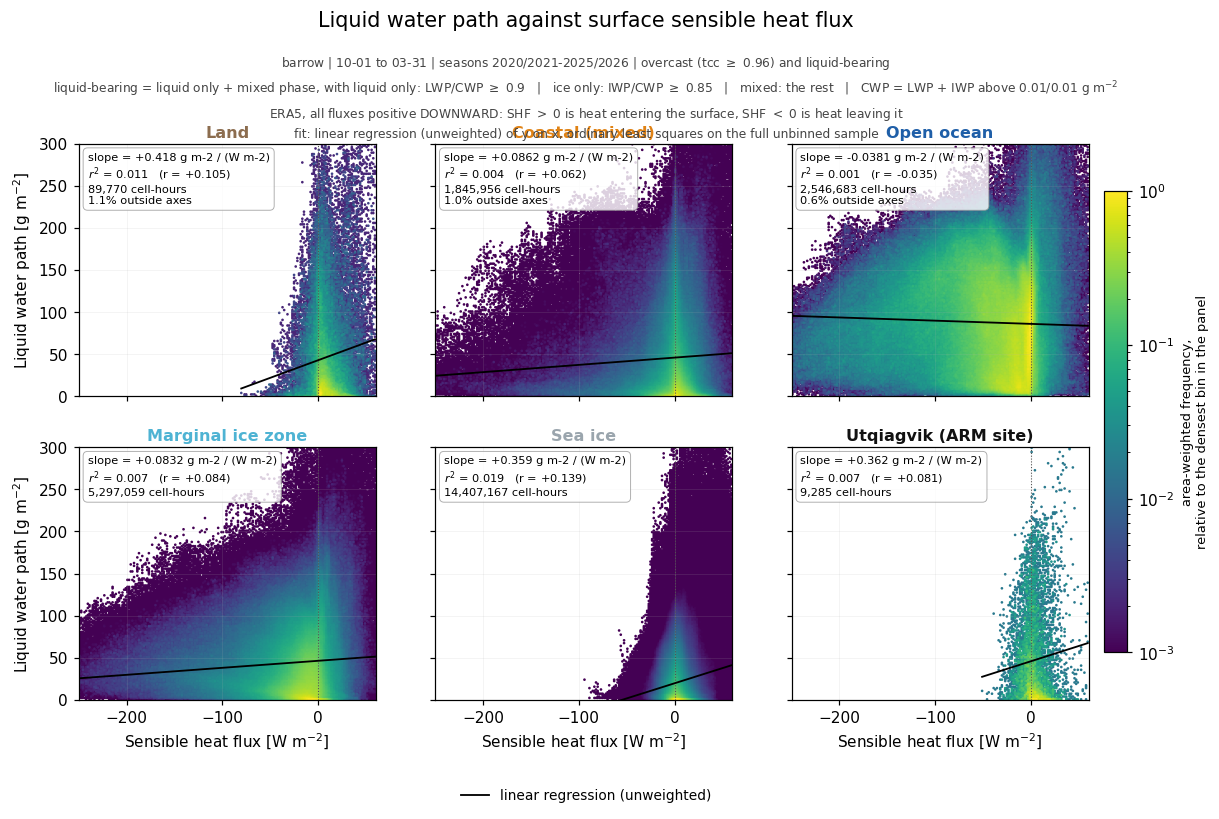

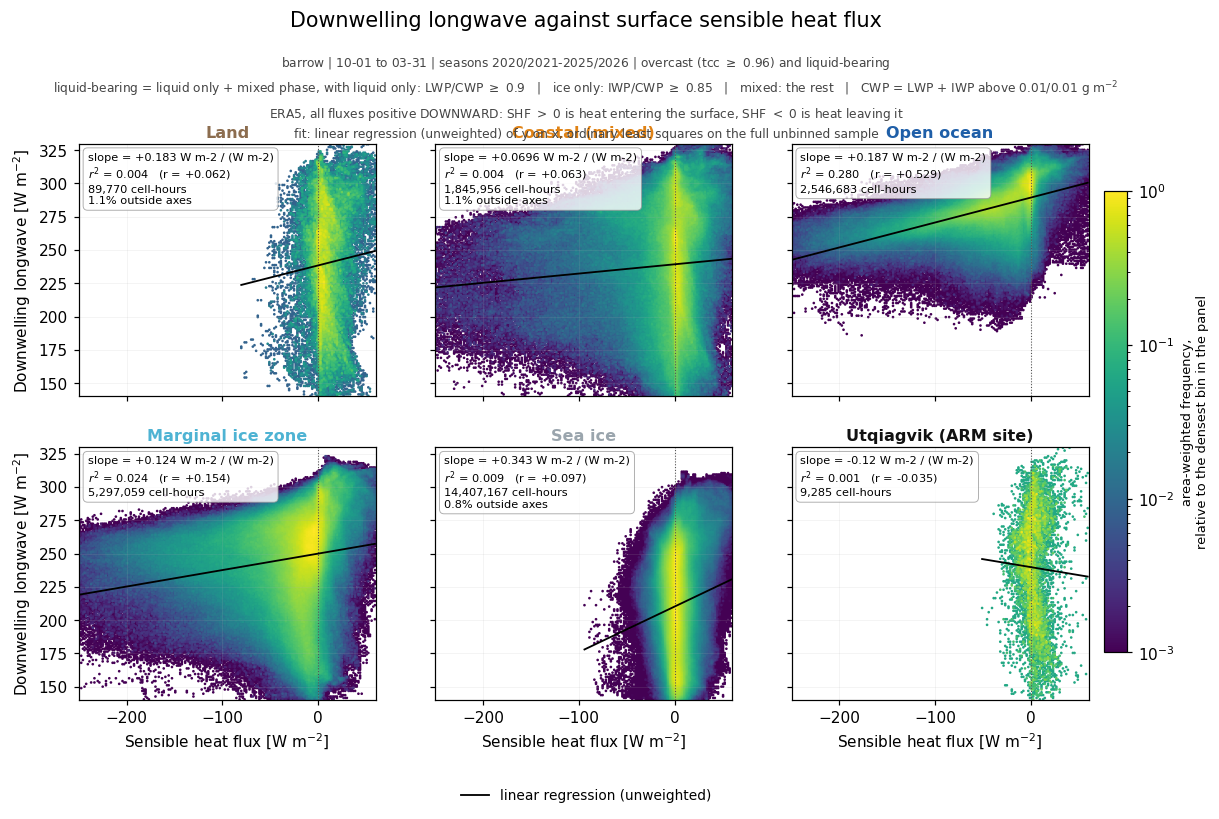

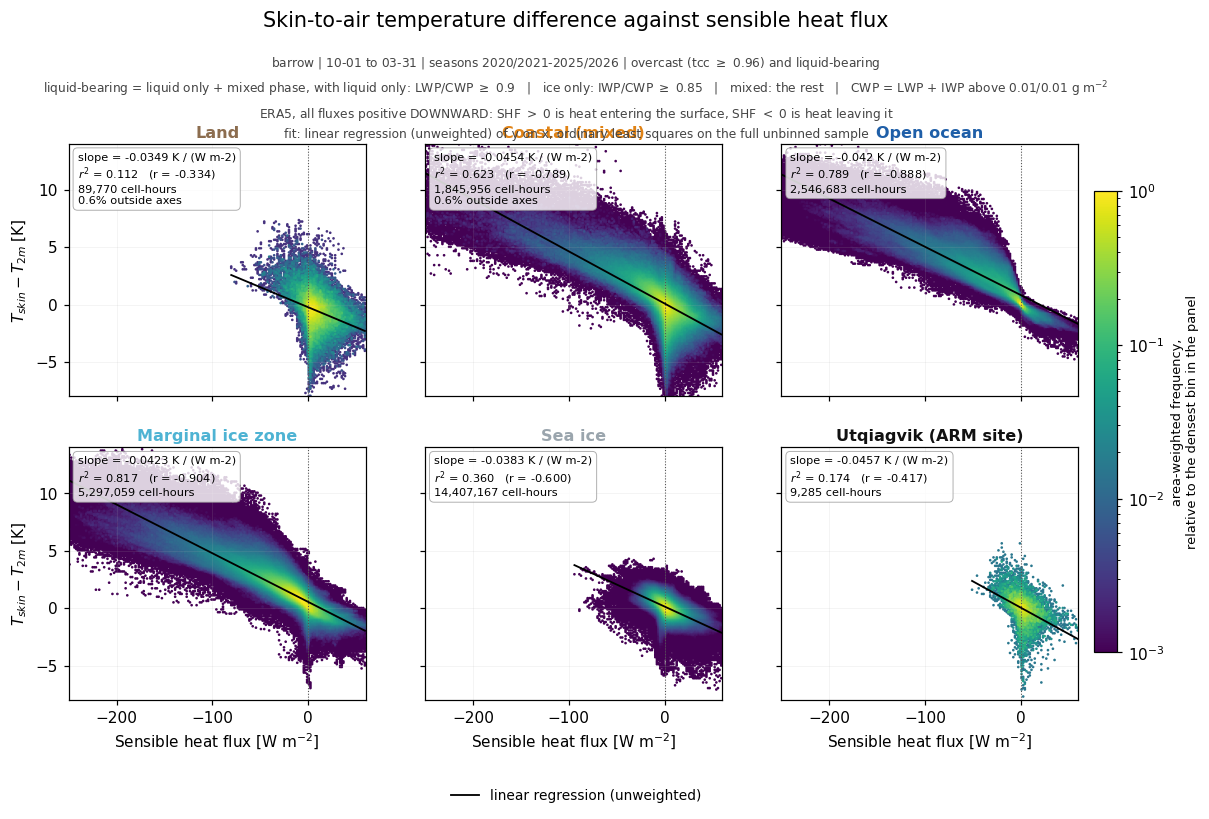

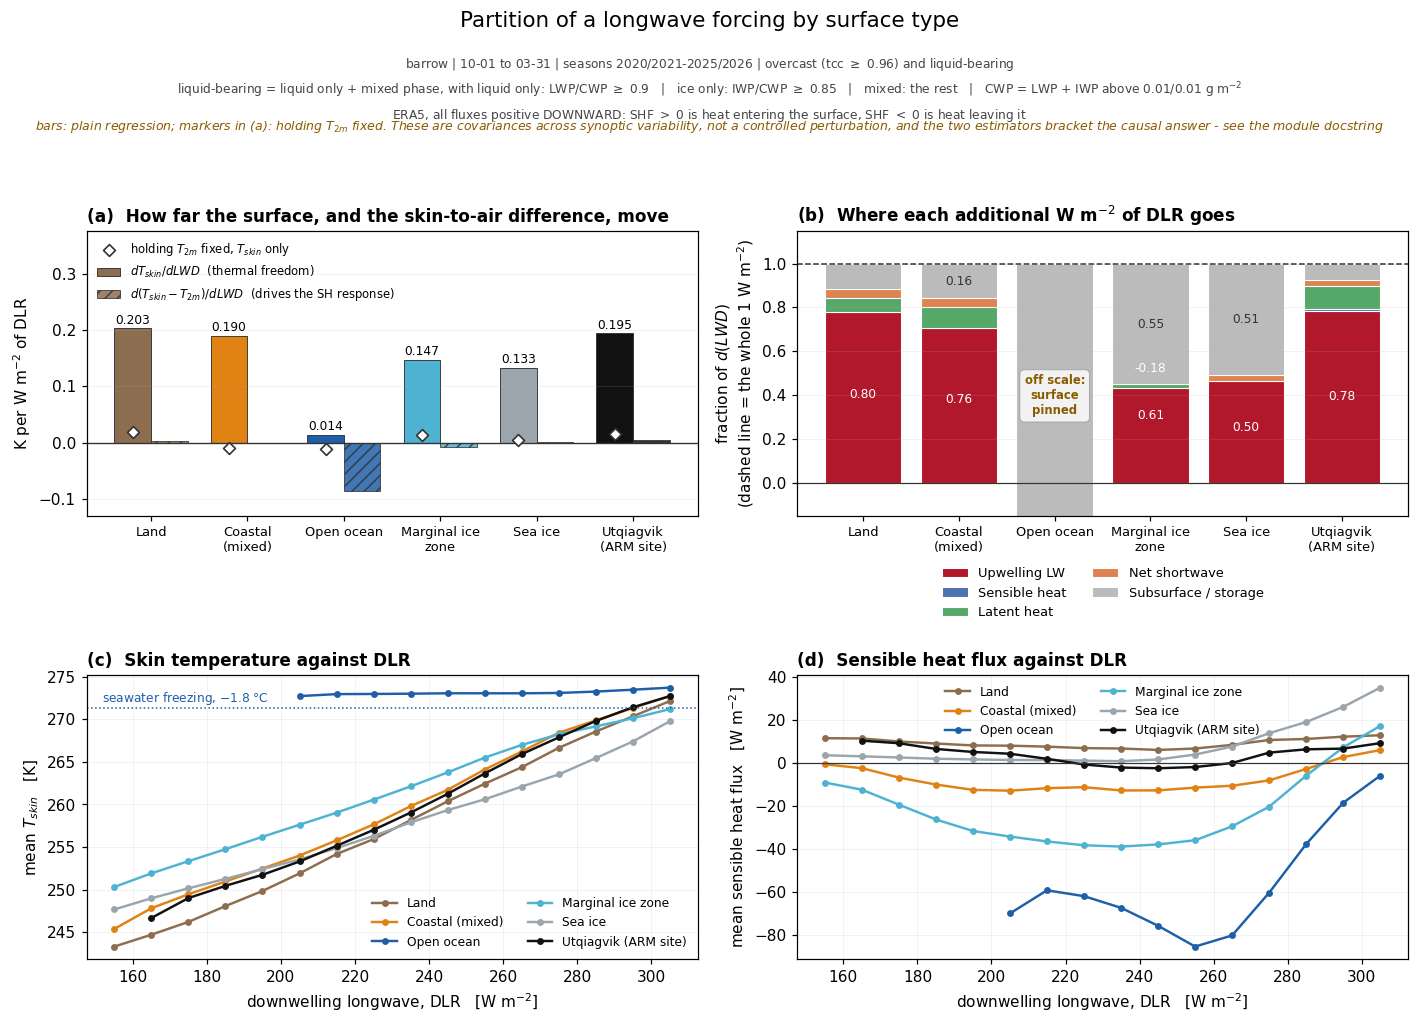

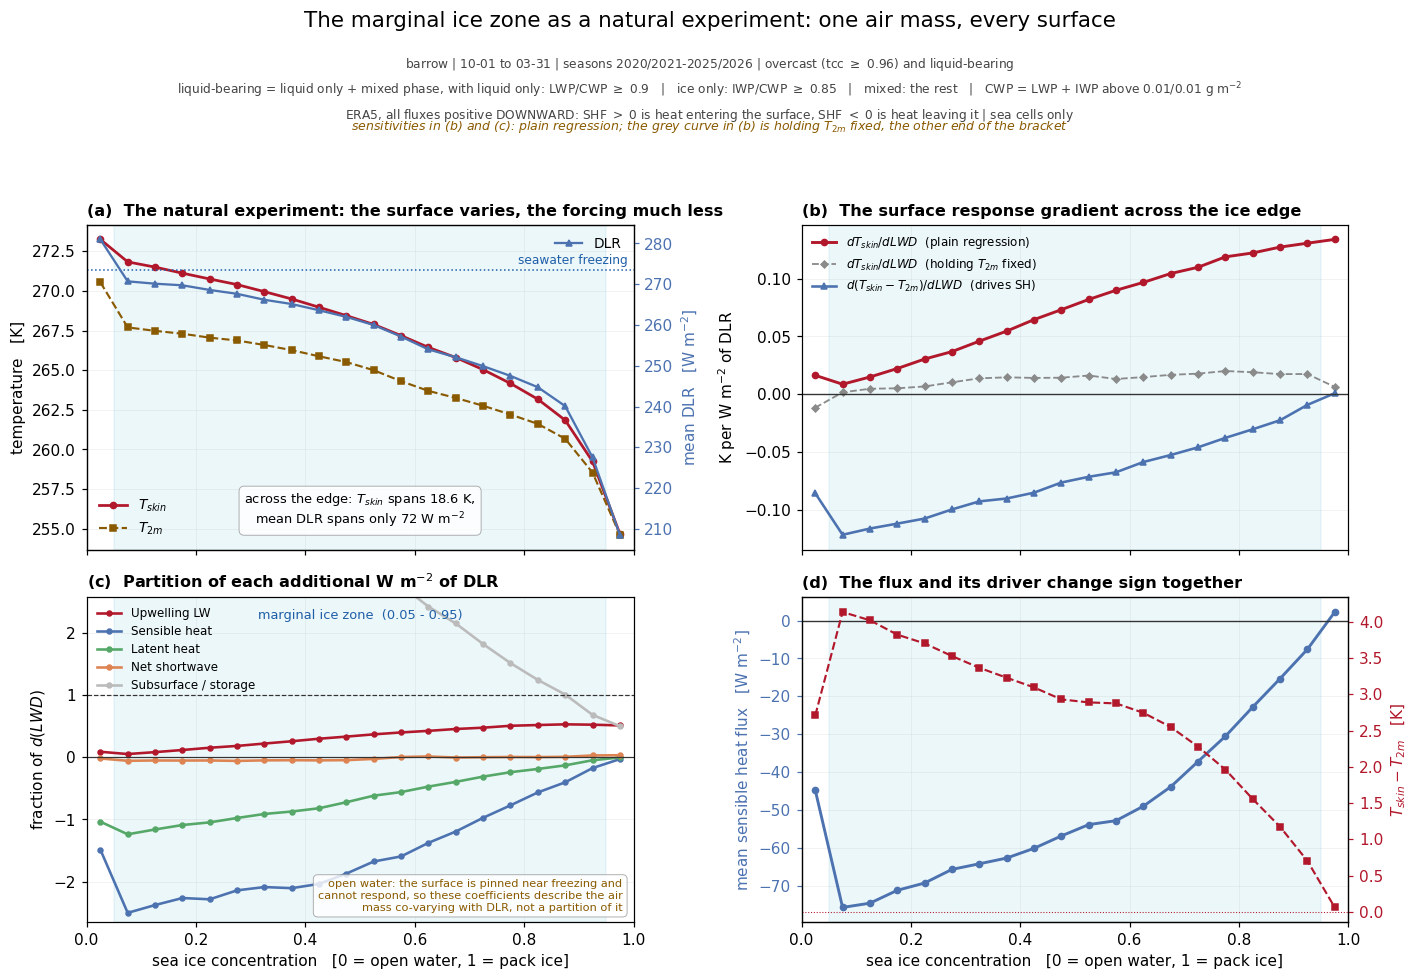

In [9]:
for fn in tfr.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR, dpi=DPI);

## Changing options

Anything that alters what is **loaded, classified or accumulated** — region,
years, season window, phase thresholds, cloud-cover gate — needs a fresh
`prepare()`, because the histograms and moments are filled during the streaming
pass:

```python
# a stricter liquid share, or a floor near a microwave radiometer's detection limit
A_strict = tfr.prepare(region="barrow", years=(2022, 2023),
                       phase_mode="fraction", liquid_fraction_min=0.95)
A_mwr = tfr.prepare(region="barrow", years=(2022, 2023),
                    phase_mode="fraction", min_lwp=25.0)

# back to the absolute g m-2 scheme, for comparison
A_abs = tfr.prepare(region="barrow", years=(2022, 2023),
                    phase_mode="absolute", liquid_lwp_min=5.0)

# midwinter only, precipitating scenes removed
A_djf = tfr.prepare(region="barrow", years=(2022, 2023),
                    season_start=(12, 1), season_end=(2, 28), no_precip=True)
```

Anything that only affects **which accumulated numbers a figure reads** can be
changed on the existing `A` with no reload, since both populations and every
control set were filled in the same pass:

```python
# swap the scatter overlay; both moment sets were accumulated in the same pass
tfr.fig_shf_vs_dlr(A, fit_mode="regression")   # thin black unweighted line
tfr.fig_shf_vs_dlr(A, fit_mode="default")      # red dashed weighted + binned mean

# the sensitivity figures for all-sky hours instead of liquid-bearing overcast
tfr.fig_response_partition(A, population="all")
tfr.fig_miz_transect(A, population="all")

# swap which estimator is the headline
tfr.fig_miz_transect(A, control="t2m")
tfr.fig_response_partition(A, control="t2m_wind")

# the report for the other population
tfr.print_report(A, population="all")
```

The three density scatters are accumulated for the liquid-bearing overcast
population only, and raise if asked for `population="all"` — the histograms are
the one thing that would need a second pass.

Individual numbers are available directly, without a figure:

```python
acc = A.acc()                       # class-slot moments, current population

# slope, intercept, r, r2, means; weighted=False for the unweighted regression
tfr.moment_stats(acc, tfr.CLASS_CODES["sea_ice"], "shf_W_m2", "lwd_W_m2")
tfr.moment_stats(acc, tfr.CLASS_CODES["sea_ice"], "shf_W_m2", "lwd_W_m2",
                 weighted=False)
tfr.partition(acc, tfr.CLASS_CODES["marginal_ice"])
tfr.partial_slope(acc, tfr.SITE_SLOT, "skt_K", "lwd_W_m2", ("t2m_K",))
```